# House Price Prediction using Machine Learning

**Author:** Dhanashree Tankar

## Project Goal
Build a machine learning model that predicts house prices using features such as:
- Area
- Bedrooms
- Bathrooms
- Age
- Location
- Property Type

## Business Context
Real estate companies need reliable pricing predictions to:
- evaluate property value
- assist buyers and sellers
- optimize pricing strategies
- analyze market trends

Machine learning models can learn patterns from historical housing data and generate accurate price predictions.

# 1. Import Libraries

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, GridSearchCV

from src.data_preprocessing import *
from src.model_training import *
from src.evaluation import *
from src.visualization import *
from src.linear_regression_scratch import LinearRegressionScratch

# 2. Load Dataset

In [3]:
data = load_data("../data/house_prices.csv")

print("Dataset shape:", data.shape)

data.head()

Dataset shape: (300, 8)


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


# 3. Exploratory Data Analysis

In [4]:
data.info()

data.isnull().sum()

data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


# 4. Data Visualization

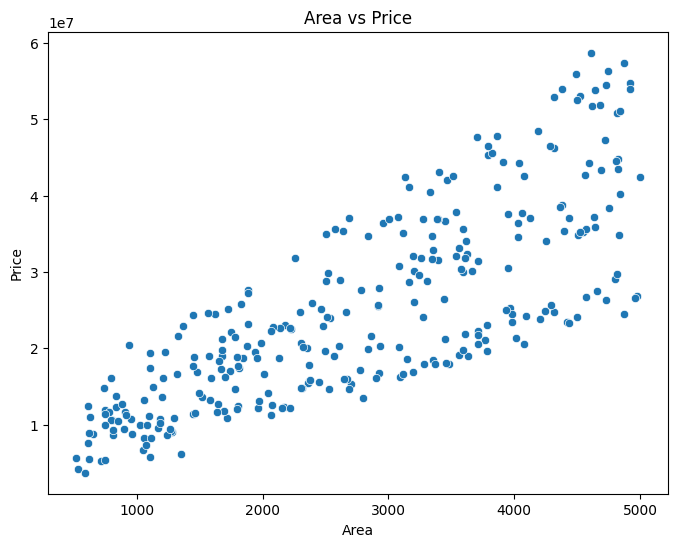

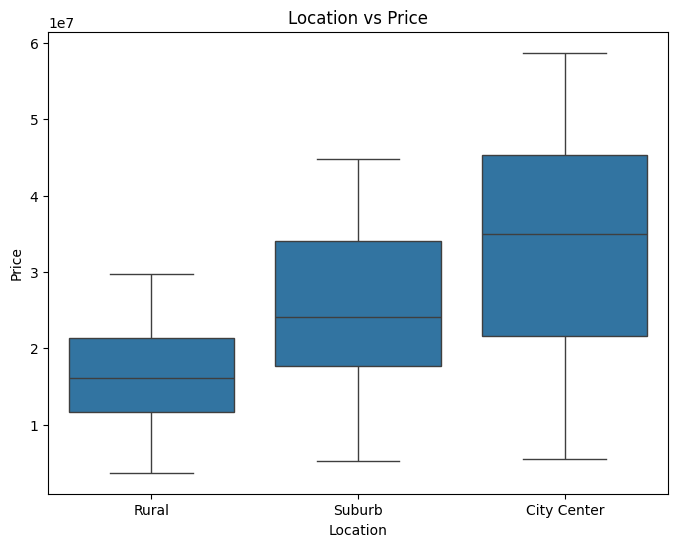

In [5]:
plot_area_vs_price(data)

plot_location_vs_price(data)

# 5. Data Preparation

In [6]:
X, y = prepare_features(data)

categorical_features = ["Location", "Property_Type"]

preprocessor = create_preprocessor(categorical_features)

X_train, X_test, y_train, y_test = split_dataset(X, y)

# 6. Linear Regression (From Scratch)

In [7]:
X_train_np = X_train[["Area","Bedrooms","Bathrooms","Age"]].values
X_test_np = X_test[["Area","Bedrooms","Bathrooms","Age"]].values

y_train_np = y_train.values

scratch_model = LinearRegressionScratch()

scratch_model.fit(X_train_np, y_train_np)

scratch_preds = scratch_model.predict(X_test_np)

scratch_metrics = evaluate_regression(y_test, scratch_preds)

print_metrics("Linear Regression (Scratch)", scratch_metrics)


Model: Linear Regression (Scratch)
------------------------------
MAE: 6,297,862.46
MSE: 60,483,339,947,903.89
RMSE: 7,777,103.57
R2: 0.58


# 7. Polynomial Regression Model

In [8]:
poly_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

poly_pipeline.fit(X_train, y_train)

poly_preds = poly_pipeline.predict(X_test)

poly_metrics = evaluate_regression(y_test, poly_preds)

print_metrics("Polynomial Regression", poly_metrics)


Model: Polynomial Regression
------------------------------
MAE: 0.00
MSE: 0.00
RMSE: 0.00
R2: 1.00


# 8. Model Training

In [9]:
lr_model = train_linear_regression(preprocessor, X_train, y_train)

dt_model = train_decision_tree(preprocessor, X_train, y_train)

rf_model = train_random_forest(preprocessor, X_train, y_train)

# 9. Feature Importance

In [10]:
feature_names = rf_model.named_steps["preprocessing"].get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
6,remainder__Area,0.687711
0,cat__Location_City Center,0.155201
1,cat__Location_Rural,0.098044
2,cat__Location_Suburb,0.028596
7,remainder__Bedrooms,0.018938
9,remainder__Age,0.007459
8,remainder__Bathrooms,0.001799
5,cat__Property_Type_Villa,0.000940
3,cat__Property_Type_Apartment,0.000748
4,cat__Property_Type_House,0.000565


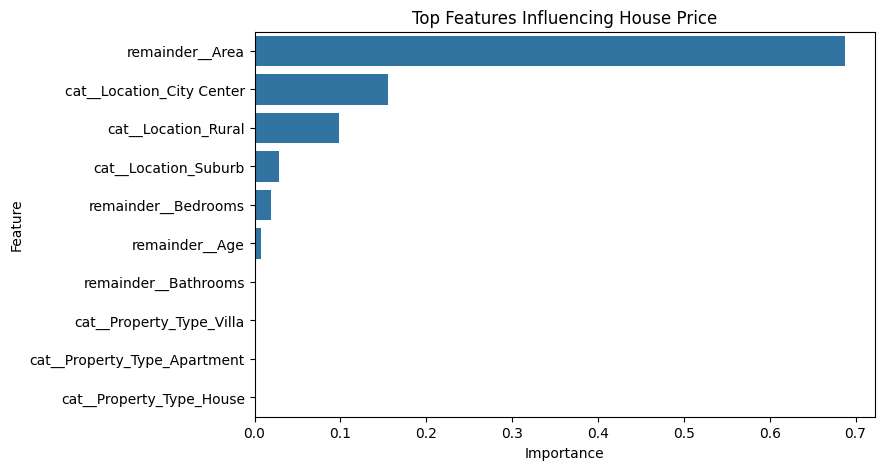

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top Features Influencing House Price")

plt.show()

# 10. Cross Validation

In [12]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.98718669 0.95046081 0.9736527  0.97129038 0.9841573 ]
Average CV Score: 0.9733495772677623


# 11. Hyperparameter Tuning

In [13]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


# 12. Predictions

In [14]:
lr_preds = lr_model.predict(X_test)

dt_preds = dt_model.predict(X_test)

rf_preds = rf_model.predict(X_test)

# 13. Model Evaluation

In [15]:
lr_metrics = evaluate_regression(y_test, lr_preds)

dt_metrics = evaluate_regression(y_test, dt_preds)

rf_metrics = evaluate_regression(y_test, rf_preds)

print_metrics("Linear Regression", lr_metrics)

print_metrics("Decision Tree", dt_metrics)

print_metrics("Random Forest", rf_metrics)


Model: Linear Regression
------------------------------
MAE: 2,188,736.34
MSE: 8,454,330,868,276.03
RMSE: 2,907,633.21
R2: 0.94

Model: Decision Tree
------------------------------
MAE: 2,125,458.33
MSE: 7,868,604,062,500.00
RMSE: 2,805,103.22
R2: 0.94

Model: Random Forest
------------------------------
MAE: 1,431,714.17
MSE: 3,641,075,846,270.83
RMSE: 1,908,160.33
R2: 0.97


# 14. Model Comparison

In [16]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        lr_metrics["R2"],
        poly_metrics["R2"],
        dt_metrics["R2"],
        rf_metrics["R2"]
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.940637
1,Polynomial Regression,1.000000
2,Decision Tree,0.944750
3,Random Forest,0.974434


# 15. Prediction Visualization

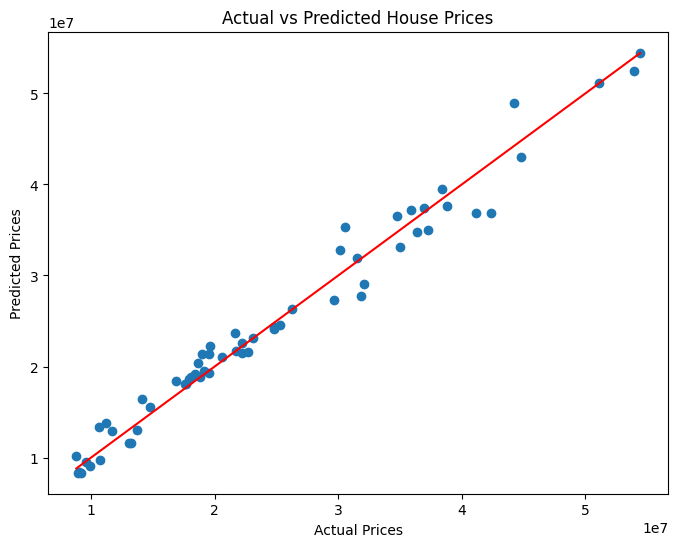

In [17]:
plot_predictions_vs_actual(
    y_test,
    rf_preds,
    "../outputs/predictions_vs_actual.png"
)

In [ ]:
plot_predictions_vs_actual(
    y_test,
    rf_preds,
    "../outputs/predictions_vs_actual.png"
)

# Conclusion

Random Forest achieved the highest R² score, indicating the best predictive performance.

## Key Insights

• Area is the strongest predictor of house price  
• Location significantly impacts property value  
• Villas tend to be priced higher than apartments  

## Model Improvements

• Polynomial regression captured nonlinear relationships  
• Cross-validation confirmed consistent model performance  
• Hyperparameter tuning improved model optimization  

## Future Improvements

• Larger housing dataset  
• Additional features such as income level or nearby facilities  
• Deploy model as a web application